# Environment Setup: Install OpenCV + scikit-image (one-time)

In [1]:
pip install opencv-python scikit-image

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 99.0 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 101.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-image] [scikit-image]]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Quick Config: Dataset root + reproducibility constants (vault, SEED, MAX_K)

In [2]:
from pathlib import Path
import re, random
from collections import defaultdict
from tqdm import tqdm

# ✅ CHANGE THIS ONE LINE to your dataset root
DATA_ROOT = Path("vault")      # e.g. Path("/path/to/vault") that contains 0001..4000 folders

SEED = 42
MAX_K = 60  # you said base indices 1..60 (odd/even pairs)

# Data Pipeline: Group split + duplicate-safe pairing (noisy-clean + seg pairs)

In [23]:
# =========================
# 0) Imports + Config
# =========================
from pathlib import Path
import re, random
from collections import defaultdict
from tqdm import tqdm

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ✅ Set this to your dataset root that contains 0001..4000 folders
DATA_ROOT = Path("vault")   # e.g. Path("/absolute/path/to/vault")

SEED = 42
MAX_K = 60  # base indices 1..60 (odd/even pairs)

PAIR_RE = re.compile(r"(?:c|cf)-(\d+)-(\d+)\.jpg$", re.IGNORECASE)


# =========================
# 1) Group split (train/val/test)
# =========================
def split_groups(train=0.8, val=0.1, max_groups=None):
    group_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])

    if max_groups is not None:
        group_dirs = group_dirs[:max_groups]

    rng = random.Random(SEED)
    rng.shuffle(group_dirs)

    n = len(group_dirs)
    n_train = int(train * n)
    n_val   = int(val   * n)

    train_g = group_dirs[:n_train]
    val_g   = group_dirs[n_train:n_train+n_val]
    test_g  = group_dirs[n_train+n_val:]
    return train_g, val_g, test_g


# =========================
# 2) Duplicate-safe pairing inside a group
#    - returns:
#      noisy_clean_pairs: (noisy_path, clean_path)  # used for mask-gen sanity + Pix2Pix later
#      seg_pairs:         (noisy_path, mask_path)   # used for U-Net training (after masks exist)
# =========================
def build_pairs_for_group_duplicates(
    gdir: Path,
    masks_root=Path("masks_soft"),
    max_k=MAX_K
):
    group_id = gdir.name  # "0577"
    idx_to_paths = defaultdict(list)

    # collect all jpgs, allow duplicates by storing lists
    for p in sorted(gdir.glob("*.jpg")):
        m = PAIR_RE.search(p.name)
        if m:
            idx = int(m.group(2))
            idx_to_paths[idx].append(p)

    # deterministic ordering inside each idx
    for idx in idx_to_paths:
        idx_to_paths[idx].sort(key=lambda x: x.name)

    noisy_clean_pairs = []
    seg_pairs = []

    # base pairing: odd k is clean, even k+1 is noisy
    for k in range(1, max_k, 2):  # 1,3,...,59
        cleans  = idx_to_paths.get(k, [])
        noisies = idx_to_paths.get(k+1, [])
        n = min(len(cleans), len(noisies))
        if n == 0:
            continue

        for i in range(n):
            clean_p = cleans[i]
            noisy_p = noisies[i]

            noisy_clean_pairs.append((str(noisy_p), str(clean_p)))

            # instance-aware mask path so duplicates never overwrite
            mask_path = masks_root / group_id / f"m-{int(group_id):04d}-{k}-{i:02d}.png"
            seg_pairs.append((str(noisy_p), str(mask_path)))

    return noisy_clean_pairs, seg_pairs


# =========================
# 3) Build split pairs (tqdm)
# =========================
def build_split_pairs(group_list, desc, masks_root=Path("masks_soft")):
    noisy_clean, seg = [], []
    for gdir in tqdm(group_list, desc=desc):
        nc, sp = build_pairs_for_group_duplicates(gdir, masks_root=masks_root)
        noisy_clean.extend(nc)
        seg.extend(sp)
    return noisy_clean, seg


# =========================
# 4) Run pairing end-to-end
# =========================
MAX_GROUPS = 3000  # change to 1000 / 2500 / etc.

train_g, val_g, test_g = split_groups(max_groups=MAX_GROUPS)
print("Groups:", len(train_g), len(val_g), len(test_g))

noisy_clean_train, seg_train = build_split_pairs(train_g, "Pairing TRAIN", masks_root=Path("masks_soft"))
noisy_clean_val,   seg_val   = build_split_pairs(val_g,   "Pairing VAL",   masks_root=Path("masks_soft"))
noisy_clean_test,  seg_test  = build_split_pairs(test_g,  "Pairing TEST",  masks_root=Path("masks_soft"))

print("Pairs (noisy_clean):", len(noisy_clean_train), len(noisy_clean_val), len(noisy_clean_test))
print("Pairs (seg):        ", len(seg_train),         len(seg_val),         len(seg_test))


# =========================
# 5) Quick sanity: show one (noisy, clean) pair
# =========================
def show_noisy_clean_pair(pair, title=None):
    noisy_path, clean_path = pair
    noisy = Image.open(noisy_path).convert("RGB")
    clean = Image.open(clean_path).convert("RGB")

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(noisy); plt.title("Noisy (Input)"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(clean); plt.title("Clean (Reference)"); plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# example:
# show_noisy_clean_pair(noisy_clean_train[0], title="Example Pair")

Groups: 2400 300 300


Pairing TEST: 100%|██████████| 300/300 [00:00<00:00, 752.52it/s]

Pairs (noisy_clean): 129546 16200 16200
Pairs (seg):         129546 16200 16200


# Data Sanity Checks: Visualize random pairs + inspect all pairs in a given group

In [7]:
# =========================
# 6) Visual checks (matplotlib)
#    - show N random noisy/clean pairs
#    - show ALL pairs from a specific group (e.g., 0577) to verify duplicates
# =========================
import random
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

def show_noisy_clean_pair(pair, title=None):
    noisy_path, clean_path = pair
    noisy = Image.open(noisy_path).convert("RGB")
    clean = Image.open(clean_path).convert("RGB")

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(noisy); plt.title("Noisy (Input)"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(clean); plt.title("Clean (Reference)"); plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_random_pairs(pairs, n=5, seed=SEED):
    rng = random.Random(seed)
    for i, pair in enumerate(rng.sample(pairs, k=min(n, len(pairs))), 1):
        show_noisy_clean_pair(pair, title=f"Random Pair {i}/{n}")

def show_group_pairs(group_id, max_k=MAX_K):
    """
    Displays all (noisy, clean) pairs found in one group directory.
    Useful to verify duplicates (e.g., groups having 1..48 repeated).
    """
    gdir = DATA_ROOT / f"{int(group_id):04d}"
    if not gdir.exists():
        raise FileNotFoundError(f"Group folder not found: {gdir}")

    noisy_clean_pairs, seg_pairs = build_pairs_for_group_duplicates(gdir, max_k=max_k)

    print(f"Group {int(group_id):04d}: noisy_clean_pairs={len(noisy_clean_pairs)}, seg_pairs={len(seg_pairs)}")
    if len(noisy_clean_pairs) == 0:
        print("No pairs found. Check naming pattern and files.")
        return

    # show in a grid: each row = (noisy, clean)
    n = len(noisy_clean_pairs)
    cols = 2
    rows = n
    plt.figure(figsize=(10, 3*rows))

    for r, (noisy_path, clean_path) in enumerate(noisy_clean_pairs):
        noisy = Image.open(noisy_path).convert("RGB")
        clean = Image.open(clean_path).convert("RGB")

        plt.subplot(rows, cols, r*2 + 1)
        plt.imshow(noisy); plt.title(f"Noisy: {Path(noisy_path).name}"); plt.axis("off")

        plt.subplot(rows, cols, r*2 + 2)
        plt.imshow(clean); plt.title(f"Clean: {Path(clean_path).name}"); plt.axis("off")

    plt.tight_layout()
    plt.show()

# ---- Run these ----
# 1) Quick random inspection from training split:
#show_random_pairs(noisy_clean_train, n=5)

# 2) Inspect one whole group (edit group_id):
#show_group_pairs(577)   # shows all pairs found in group 0577

# Pseudo Ground Truth Masks (Binary): HSV stamp suppression + Otsu + CC filtering + light closing

In [8]:
# =========================
# 7) Binary mask generation (from CLEAN) + save to seg_pairs mask_path
# =========================
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm

MASKS_ROOT = Path("masks")  # same root used in pairing

def make_signature_mask_from_clean_bgr(clean_bgr,
                                       min_area=20,
                                       close_ksize=3,
                                       close_iter=1,
                                       sat_thr=60,
                                       val_thr=60):
    """
    Pseudo-GT binary mask from CLEAN image (BGR):
      1) stamp suppression by HSV (red + high-saturation)
      2) ink extraction via Otsu (inverse)
      3) connected components filter (keeps thin strokes better than area-less filtering)
      4) light morphological close (connect minor gaps)
    Returns uint8 mask {0,255}
    """
    hsv = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    stamp_red = ((s > 80) & (v > 50) & (((h >= 0) & (h <= 15)) | ((h >= 160) & (h <= 180))))
    stamp_red = stamp_red.astype(np.uint8) * 255

    stamp_sat = ((s >= sat_thr) & (v >= val_thr)).astype(np.uint8) * 255

    k_stamp = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    stamp_any = cv2.max(stamp_red, stamp_sat)
    stamp_any = cv2.dilate(stamp_any, k_stamp, iterations=1)

    gray = cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2GRAY)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # remove stamp-like pixels from ink
    bw[stamp_any > 0] = 0

    # connected components to remove tiny specks
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)
    cleaned = np.zeros_like(bw)

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == i] = 255

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_ksize, close_ksize))
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, k_close, iterations=close_iter)

    return cleaned


def generate_masks_from_noisy_clean_pairs(noisy_clean_pairs, seg_pairs, overwrite=False,
                                         min_area=20, close_ksize=3, close_iter=1,
                                         sat_thr=60, val_thr=60):
    """
    Uses (noisy, clean) pairs to generate mask from CLEAN and saves to mask_path from seg_pairs.
    Assumes noisy_clean_pairs and seg_pairs have same length and order (they do if built together).
    """
    assert len(noisy_clean_pairs) == len(seg_pairs), "Length mismatch between pairs and seg_pairs"

    written, skipped, failed = 0, 0, 0
    for (noisy_path, clean_path), (noisy2_path, mask_path_str) in tqdm(
        list(zip(noisy_clean_pairs, seg_pairs)),
        desc="Generating masks"
    ):
        # safety: ensure alignment
        if noisy_path != noisy2_path:
            raise ValueError("Pair alignment mismatch (noisy paths differ). Rebuild pairs together.")

        mask_path = Path(mask_path_str)
        if mask_path.exists() and not overwrite:
            skipped += 1
            continue

        mask_path.parent.mkdir(parents=True, exist_ok=True)

        clean_bgr = cv2.imread(clean_path, cv2.IMREAD_COLOR)
        if clean_bgr is None:
            failed += 1
            continue

        mask255 = make_signature_mask_from_clean_bgr(
            clean_bgr,
            min_area=min_area,
            close_ksize=close_ksize,
            close_iter=close_iter,
            sat_thr=sat_thr,
            val_thr=val_thr
        )

        ok = cv2.imwrite(str(mask_path), mask255)
        if ok:
            written += 1
        else:
            failed += 1

    print(f"Done. written={written}, skipped={skipped}, failed={failed}")

# Mask Generation Run: Create binary masks for TRAIN and VAL splits

In [9]:
# =========================
# 8) Generate masks for TRAIN + VAL (recommended)
# =========================
generate_masks_from_noisy_clean_pairs(
    noisy_clean_train, seg_train,
    overwrite=False,   # set True if you want to regenerate/replace
    min_area=20,
    close_ksize=3,
    close_iter=1,
    sat_thr=60,
    val_thr=60
)

generate_masks_from_noisy_clean_pairs(
    noisy_clean_val, seg_val,
    overwrite=False,
    min_area=20,
    close_ksize=3,
    close_iter=1,
    sat_thr=60,
    val_thr=60
)

Generating masks: 100%|██████████| 129546/129546 [16:14<00:00, 132.92it/s]


Done. written=129546, skipped=0, failed=0


Generating masks: 100%|██████████| 16200/16200 [02:02<00:00, 132.33it/s]

Done. written=16200, skipped=0, failed=0


# Mask Overlay Visualization: Noisy vs Clean vs Mask vs Overlay (resize-safe)

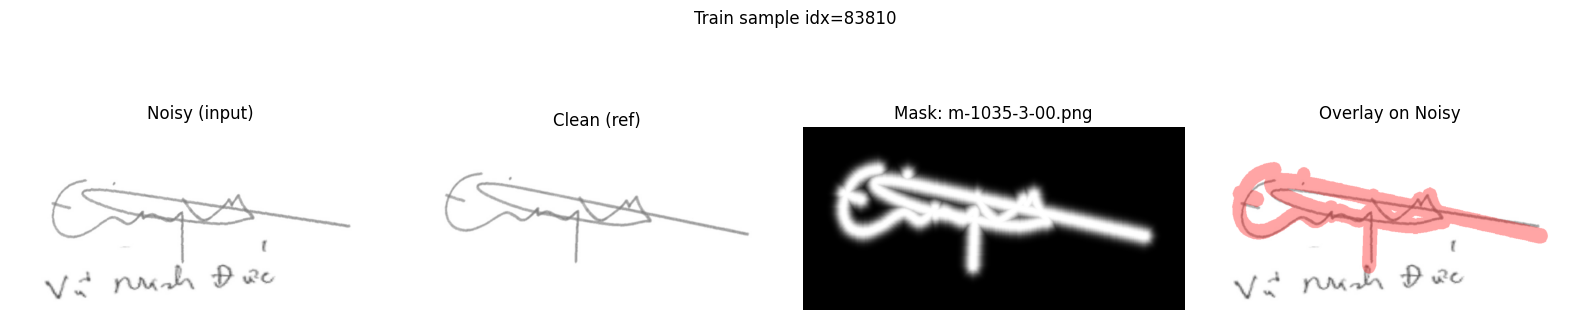

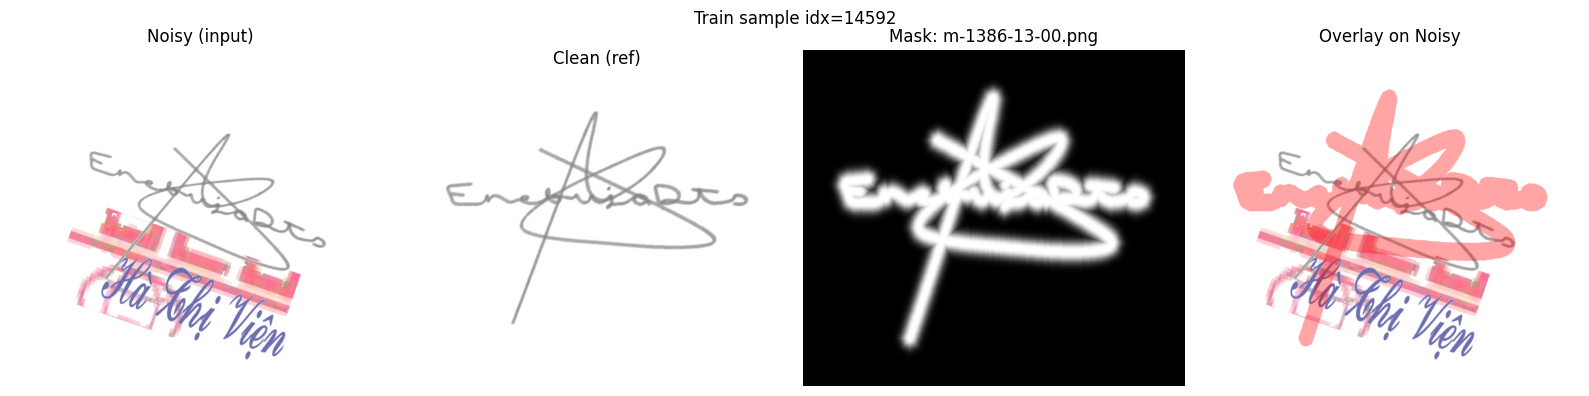

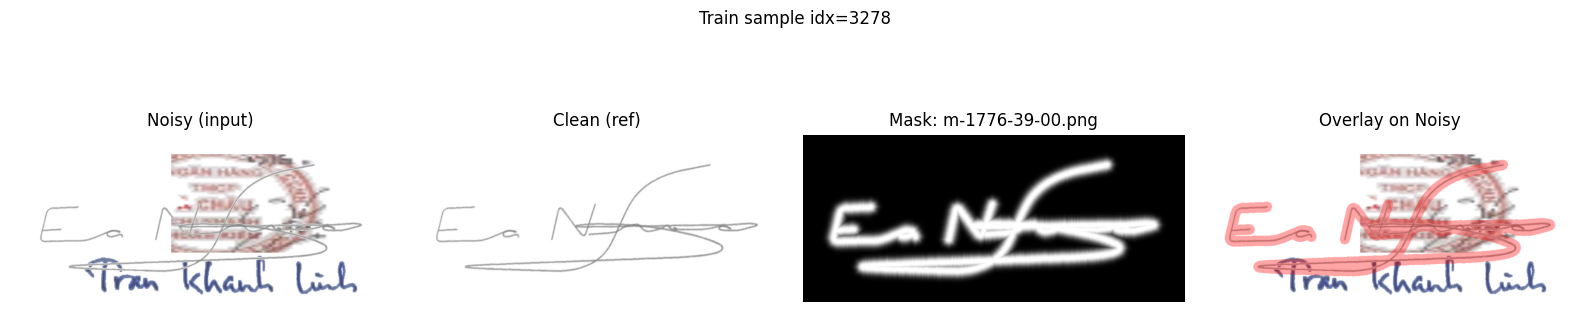

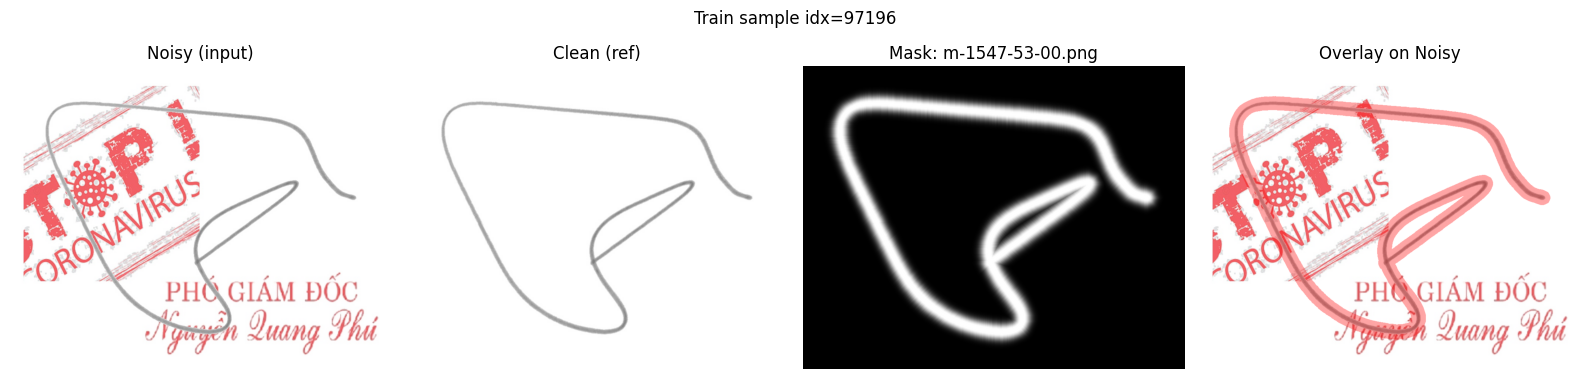

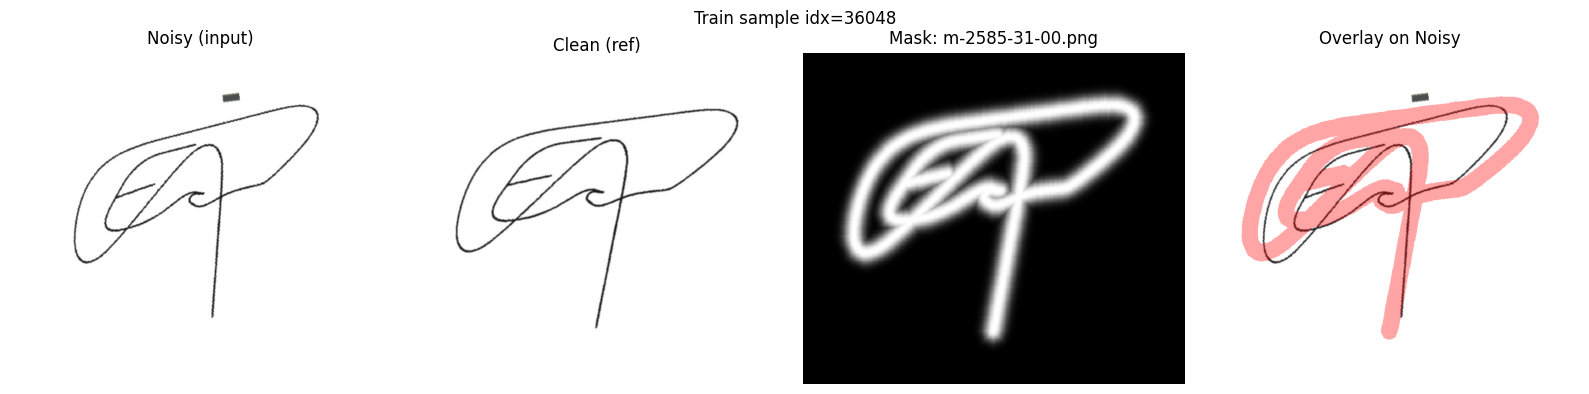

In [24]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

def show_noisy_clean_mask(noisy_clean_pair, seg_pair, title=None):
    noisy_path, clean_path = noisy_clean_pair
    _, mask_path = seg_pair

    noisy = np.array(Image.open(noisy_path).convert("RGB"))
    clean = np.array(Image.open(clean_path).convert("RGB"))

    m = np.array(Image.open(mask_path).convert("L"))  # 0..255

    # ✅ resize mask to noisy size
    m = cv2.resize(m, (noisy.shape[1], noisy.shape[0]), interpolation=cv2.INTER_NEAREST)
    m01 = (m > 127).astype(np.uint8)

    overlay = noisy.copy()
    alpha = 0.35
    overlay[m01 == 1] = (overlay[m01 == 1] * (1 - alpha) + np.array([255, 0, 0]) * alpha).astype(np.uint8)

    plt.figure(figsize=(16,4))
    plt.subplot(1,4,1); plt.imshow(noisy);   plt.title("Noisy (input)"); plt.axis("off")
    plt.subplot(1,4,2); plt.imshow(clean);   plt.title("Clean (ref)");   plt.axis("off")
    plt.subplot(1,4,3); plt.imshow(m, cmap="gray"); plt.title(f"Mask: {Path(mask_path).name}"); plt.axis("off")
    plt.subplot(1,4,4); plt.imshow(overlay); plt.title("Overlay on Noisy"); plt.axis("off")
    if title: plt.suptitle(title)
    plt.tight_layout()
    plt.show()
# show 5 random TRAIN examples
rng = random.Random(SEED)
for _ in range(5):
    i = rng.randrange(len(noisy_clean_train))
    show_noisy_clean_mask(noisy_clean_train[i], seg_train[i], title=f"Train sample idx={i}")

# Soft Mask Conversion: Binary → distance-transform soft target (masks → masks_soft)

In [20]:
from pathlib import Path
import cv2, numpy as np
from tqdm import tqdm

BIN_ROOT  = Path("masks")
SOFT_ROOT = Path("masks_soft")

def bin_to_soft_mask(mask_u8_255, sigma=12.0, clip_max=64):
    """
    Input: binary uint8 mask in {0,255} where ink=255.
    Output: soft float mask in [0,255] (uint8) with smooth boundary weighting.
    """
    m = (mask_u8_255 > 127).astype(np.uint8)

    # distance to foreground (ink) and to background
    dist_bg = cv2.distanceTransform(1 - m, cv2.DIST_L2, 3)  # outside ink
    dist_fg = cv2.distanceTransform(m,     cv2.DIST_L2, 3)  # inside ink

    # make a signed distance: negative inside ink, positive outside
    sdf = dist_bg - dist_fg

    # clamp and convert to soft probability: 1 near ink, decays away
    sdf = np.clip(sdf, -clip_max, clip_max)
    soft = np.exp(-(np.maximum(sdf, 0) ** 2) / (2 * (sigma ** 2)))  # outside decay
    soft[m == 1] = 1.0  # inside ink = 1

    return (soft * 255).astype(np.uint8)

def generate_soft_masks(overwrite=False, sigma=12.0, clip_max=64):
    soft_written, skipped = 0, 0
    for mp in tqdm(list(BIN_ROOT.rglob("*.png")), desc="Binary → Soft masks"):
        rel = mp.relative_to(BIN_ROOT)          # e.g. 1035/m-1035-3-00.png
        outp = SOFT_ROOT / rel                  # e.g. masks_soft/1035/m-...
        outp.parent.mkdir(parents=True, exist_ok=True)

        if outp.exists() and not overwrite:
            skipped += 1
            continue

        m = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if m is None:
            continue

        soft = bin_to_soft_mask(m, sigma=sigma, clip_max=clip_max)
        cv2.imwrite(str(outp), soft)
        soft_written += 1

    print(f"Done. soft_written={soft_written}, skipped={skipped}")

generate_soft_masks(overwrite=False, sigma=12.0, clip_max=64)

Binary → Soft masks: 100%|██████████| 145746/145746 [23:30<00:00, 103.34it/s]

Done. soft_written=145746, skipped=0


# tf.data Loader + Augmentation: Random Contrast + Random Grayscale (train-time only)

In [25]:
import tensorflow as tf

IMG_SIZE = (512, 512)
BATCH = 16
AUTOTUNE = tf.data.AUTOTUNE

def aug_noisy(x):
    x = tf.image.random_contrast(x, 0.6, 1.4)
    if tf.random.uniform(()) < 0.5:
        x = tf.image.rgb_to_grayscale(x)
        x = tf.image.grayscale_to_rgb(x)
    return tf.clip_by_value(x, 0.0, 1.0)

def parse_seg(noisy_path, mask_path, training=True):
    noisy = tf.io.decode_jpeg(tf.io.read_file(noisy_path), channels=3)
    noisy = tf.image.resize(noisy, IMG_SIZE)
    noisy = tf.cast(noisy, tf.float32) / 255.0

    mask = tf.io.decode_png(tf.io.read_file(mask_path), channels=1)  # soft mask png
    mask = tf.image.resize(mask, IMG_SIZE, method="nearest")
    mask = tf.cast(mask, tf.float32) / 255.0

    if training:
        noisy = aug_noisy(noisy)

    return noisy, mask

def make_seg_dataset(seg_pairs, training=True, batch=BATCH):
    noisy_paths = [p for (p, m) in seg_pairs]
    mask_paths  = [m for (p, m) in seg_pairs]

    ds = tf.data.Dataset.from_tensor_slices((noisy_paths, mask_paths))
    if training:
        ds = ds.shuffle(4096, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(lambda n, m: parse_seg(n, m, training=training),
                num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return ds

train_ds = make_seg_dataset(seg_train, training=True)
val_ds   = make_seg_dataset(seg_val,   training=False)
test_ds  = make_seg_dataset(seg_test,  training=False)

I0000 00:00:1771002681.962224     117 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 140829 MB memory:  -> device: 0, name: NVIDIA H200 NVL, pci bus id: 0000:01:00.0, compute capability: 9.0
E0000 00:00:1771002682.164162    1050 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.3.107, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


# Dataset Integrity Check: Verify batch shapes, dtypes, and value ranges

In [26]:
for x, y in train_ds.take(1):
    print(x.shape, x.dtype, float(tf.reduce_min(x)), float(tf.reduce_max(x)))
    print(y.shape, y.dtype, float(tf.reduce_min(y)), float(tf.reduce_max(y)))

(16, 512, 512, 3) <dtype: 'float32'> 0.0 1.0
(16, 512, 512, 1) <dtype: 'float32'> 0.0 1.0


# Evaluation Metrics (Soft-GT Aware): IoU / Precision / Recall computed after binarizing soft targets

In [27]:
import tensorflow as tf

THR = 0.5

def _bin(y, thr=THR):
    return tf.cast(y >= thr, tf.float32)

@tf.function
def iou(y_true, y_pred):
    yt = _bin(y_true, 0.5)                 # y_true is soft, binarize for metric
    yp = _bin(y_pred, THR)
    inter = tf.reduce_sum(yt * yp, axis=[1,2,3])
    union = tf.reduce_sum(yt + yp, axis=[1,2,3]) - inter
    return tf.reduce_mean((inter + 1e-7) / (union + 1e-7))

@tf.function
def precision(y_true, y_pred):
    yt = _bin(y_true, 0.5)
    yp = _bin(y_pred, THR)
    tp = tf.reduce_sum(yt * yp, axis=[1,2,3])
    fp = tf.reduce_sum((1-yt) * yp, axis=[1,2,3])
    return tf.reduce_mean((tp + 1e-7) / (tp + fp + 1e-7))

@tf.function
def recall(y_true, y_pred):
    yt = _bin(y_true, 0.5)
    yp = _bin(y_pred, THR)
    tp = tf.reduce_sum(yt * yp, axis=[1,2,3])
    fn = tf.reduce_sum(yt * (1-yp), axis=[1,2,3])
    return tf.reduce_mean((tp + 1e-7) / (tp + fn + 1e-7))

@tf.function
def f1(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return (2*p*r) / (p + r + 1e-7)

@tf.function
def pixel_acc(y_true, y_pred):
    yt = _bin(y_true, 0.5)
    yp = _bin(y_pred, THR)
    eq = tf.cast(tf.equal(yt, yp), tf.float32)
    return tf.reduce_mean(eq)

# Loss Functions: Soft Dice + BCE-Dice

In [28]:
def dice_loss_soft(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0-1e-7)
    # IMPORTANT: keep y_true as soft; do NOT binarize for loss
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    denom = tf.reduce_sum(y_true + y_pred, axis=[1,2,3])
    dice = (2.0*inter + 1e-7) / (denom + 1e-7)
    return 1.0 - tf.reduce_mean(dice)

def bce_dice_loss_soft(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    return bce + dice_loss_soft(y_true, y_pred)

# U-Net Architecture: Encoder–Decoder with skip connections (Conv-BN-ReLU blocks)

In [29]:
def conv_block(x, f, name):
    x = tf.keras.layers.Conv2D(f, 3, padding="same", use_bias=False, name=name+"_c1")(x)
    x = tf.keras.layers.BatchNormalization(name=name+"_bn1")(x)
    x = tf.keras.layers.ReLU(name=name+"_r1")(x)

    x = tf.keras.layers.Conv2D(f, 3, padding="same", use_bias=False, name=name+"_c2")(x)
    x = tf.keras.layers.BatchNormalization(name=name+"_bn2")(x)
    x = tf.keras.layers.ReLU(name=name+"_r2")(x)
    return x

def unet(input_shape=(512,512,3), base=64):
    inp = tf.keras.Input(shape=input_shape)

    # Encoder
    c1 = conv_block(inp, base,   "enc1"); p1 = tf.keras.layers.MaxPooling2D()(c1)
    c2 = conv_block(p1,  base*2, "enc2"); p2 = tf.keras.layers.MaxPooling2D()(c2)
    c3 = conv_block(p2,  base*4, "enc3"); p3 = tf.keras.layers.MaxPooling2D()(c3)
    c4 = conv_block(p3,  base*8, "enc4"); p4 = tf.keras.layers.MaxPooling2D()(c4)

    # Bottleneck
    bn = conv_block(p4, base*16, "bottleneck")

    # Decoder
    u4 = tf.keras.layers.UpSampling2D(interpolation="bilinear")(bn)
    u4 = tf.keras.layers.Concatenate()([u4, c4])
    d4 = conv_block(u4, base*8, "dec4")

    u3 = tf.keras.layers.UpSampling2D(interpolation="bilinear")(d4)
    u3 = tf.keras.layers.Concatenate()([u3, c3])
    d3 = conv_block(u3, base*4, "dec3")

    u2 = tf.keras.layers.UpSampling2D(interpolation="bilinear")(d3)
    u2 = tf.keras.layers.Concatenate()([u2, c2])
    d2 = conv_block(u2, base*2, "dec2")

    u1 = tf.keras.layers.UpSampling2D(interpolation="bilinear")(d2)
    u1 = tf.keras.layers.Concatenate()([u1, c1])
    d1 = conv_block(u1, base, "dec1")

    out = tf.keras.layers.Conv2D(1, 1, activation="sigmoid", name="mask")(d1)
    return tf.keras.Model(inp, out, name="UNet_Signature")

In [30]:
model = unet(input_shape=(512,512,3), base=32)  # base=32 is usually enough; base=64 if you want heavier
model.summary()

Model: "UNet_Signature"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c1 (Conv2D)    │ (None, 512, 512,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 512, 512,  │        128 │ enc1_c1[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_r1 (ReLU)      │ (None, 512, 512,  │          0 │ enc1_bn1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c2 (Conv2D)    │ (None, 512, 512,  │      9,216 │ enc1_r1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 512, 512,  │        128 │ enc1_c2[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_r2 (ReLU)      │ (None, 512, 512,  │          0 │ enc1_bn2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ enc1_r2[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c1 (Conv2D)    │ (None, 256, 256,  │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 256, 256,  │        256 │ enc2_c1[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_r1 (ReLU)      │ (None, 256, 256,  │          0 │ enc2_bn1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c2 (Conv2D)    │ (None, 256, 256,  │     36,864 │ enc2_r1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 256, 256,  │        256 │ enc2_c2[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_r2 (ReLU)      │ (None, 256, 256,  │          0 │ enc2_bn2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ enc2_r2[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_c1 (Conv2D)    │ (None, 128, 128,  │     73,728 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 128, 128,  │        512 │ enc3_c1[0][0]   

 Total params: 7,855,489 (29.97 MB)

 Trainable params: 7,849,601 (29.94 MB)

 Non-trainable params: 5,888 (23.00 KB)

# Training Setup: Callbacks + compile (Adam, BCE+SoftDice) + fit on soft-mask dataset

In [31]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "unet_soft_best.keras", monitor="val_iou", mode="max", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_iou", mode="max", patience=7, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_iou", mode="max", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=bce_dice_loss_soft,
    metrics=[iou, precision, recall, f1, pixel_acc]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40


2026-02-13 17:14:16.503510: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv (f32[16,64,64,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,64,768]{3,2,1,0}, f32[256,3,3,768]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-02-13 17:14:17.071847: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.56847698s
Trying algorithm eng0{} for conv (f32[16,64,64,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,64,768]{3,2,1,0}, f32[256,3,3,768]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","

   2/8097 ━━━━━━━━━━━━━━━━━━━━ 9:30 70ms/step - f1: 0.3624 - iou: 0.2211 - loss: 1.4060 - pixel_acc: 0.7034 - precision: 0.2880 - recall: 0.5059    

I0000 00:00:1771002898.878284    1042 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8096/8097 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - f1: 0.7445 - iou: 0.6262 - loss: 0.6157 - pixel_acc: 0.9103 - precision: 0.7090 - recall: 0.7855

2026-02-13 17:44:47.594265: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 17:44:47.725419: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 17:44:48.179638: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 17:44:48.320626: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-13 17:44:49.935932: E external/local_xla/xla/stream_

8097/8097 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - f1: 0.7445 - iou: 0.6262 - loss: 0.6157 - pixel_acc: 0.9103 - precision: 0.7090 - recall: 0.7855
Epoch 1: val_iou improved from None to 0.58081, saving model to unet_soft_best.keras
8097/8097 ━━━━━━━━━━━━━━━━━━━━ 2014s 242ms/step - f1: 0.7789 - iou: 0.6698 - loss: 0.5540 - pixel_acc: 0.9216 - precision: 0.7390 - recall: 0.8244 - val_f1: 0.7157 - val_iou: 0.5808 - val_loss: 0.6667 - val_pixel_acc: 0.9113 - val_precision: 0.7169 - val_recall: 0.7190 - learning_rate: 0.0010
Epoch 2/40
8096/8097 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - f1: 0.8299 - iou: 0.7330 - loss: 0.4767 - pixel_acc: 0.9388 - precision: 0.7851 - recall: 0.8809
Epoch 2: val_iou improved from 0.58081 to 0.68921, saving model to unet_soft_best.keras
8097/8097 ━━━━━━━━━━━━━━━━━━━━ 1900s 235ms/step - f1: 0.8370 - iou: 0.7424 - loss: 0.4663 - pixel_acc: 0.9415 - precision: 0.7921 - recall: 0.8881 - val_f1: 0.8020 - val_iou: 0.6892 - val_loss: 0.4959 - val_pixel_acc: 0.9275 - val_pre

# Qualitative Results: Visualize predictions vs soft GT + thresholded mask

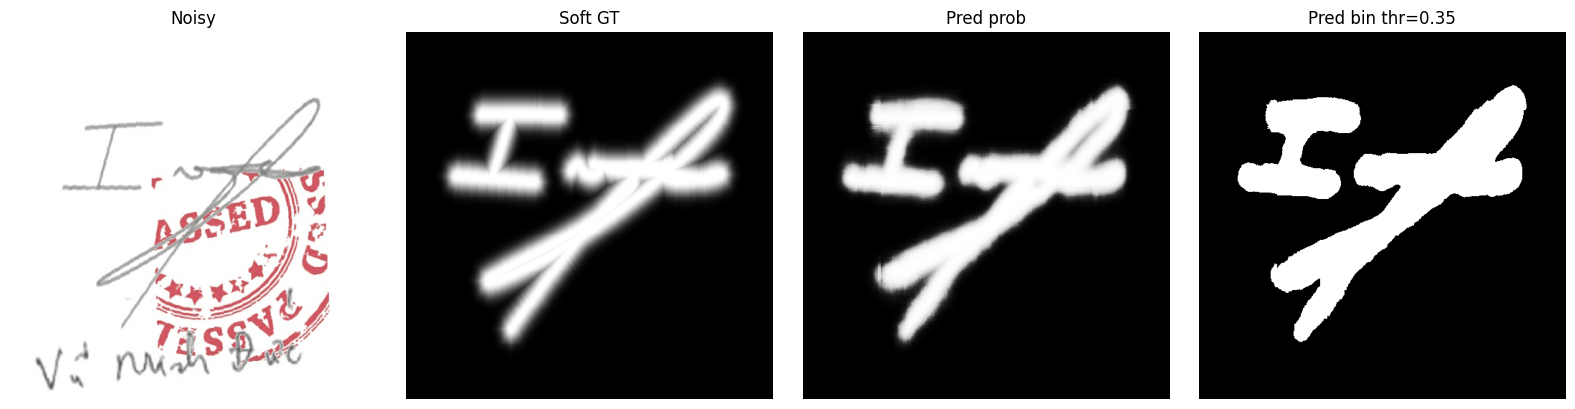

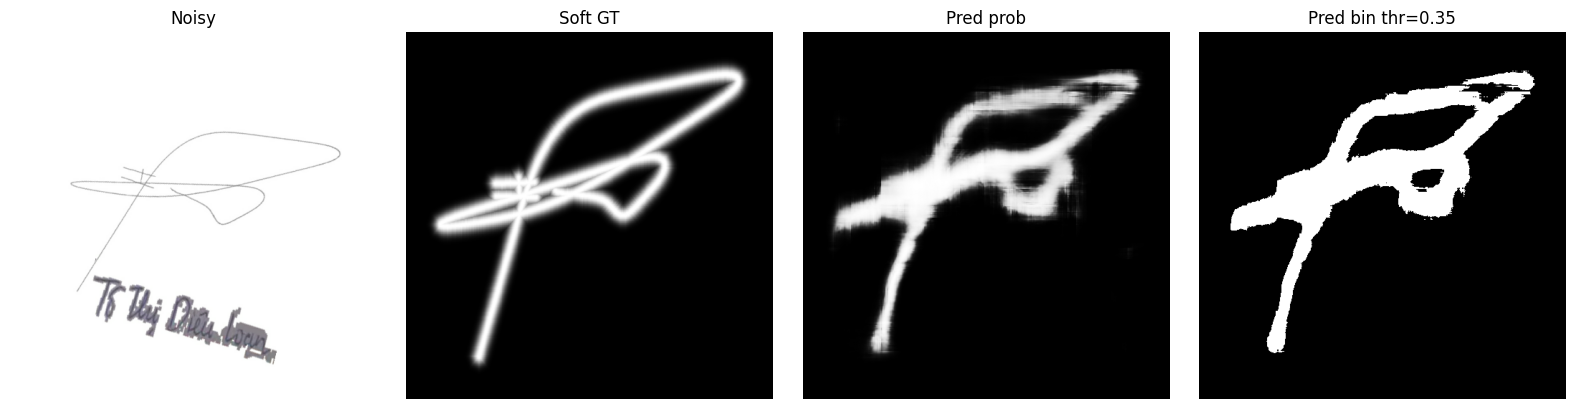

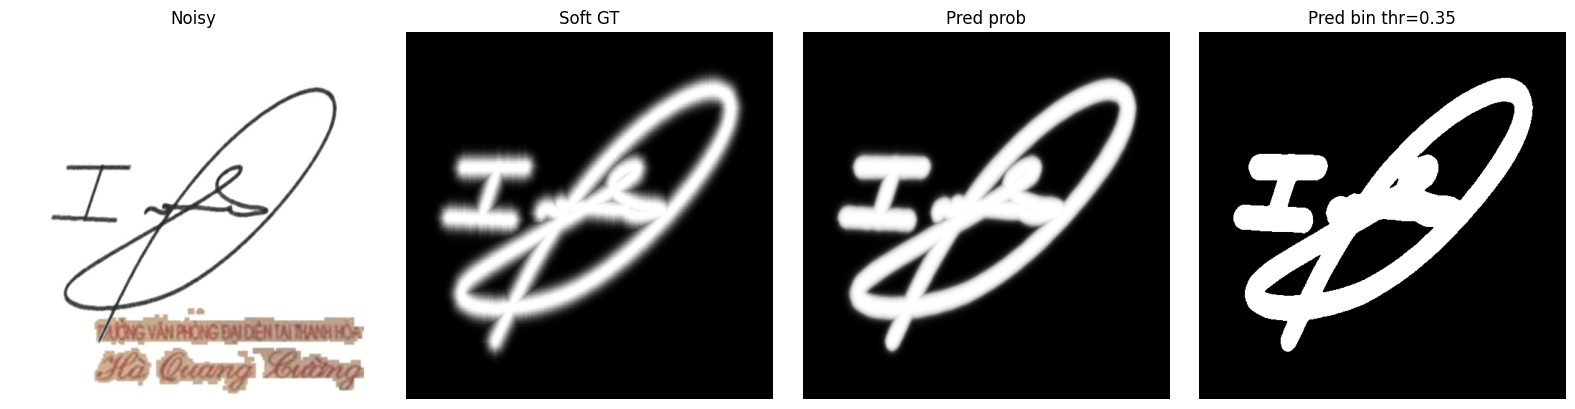

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def show_preds(model, ds, n=3, thr=0.5):
    for x, y in ds.take(1):
        p = model.predict(x, verbose=0)
        for i in range(min(n, x.shape[0])):
            xi = x[i].numpy()
            yi = y[i].numpy()[...,0]
            pi = p[i,...,0]
            bi = (pi >= thr).astype(np.float32)

            plt.figure(figsize=(16,4))
            plt.subplot(1,4,1); plt.imshow(xi); plt.title("Noisy"); plt.axis("off")
            plt.subplot(1,4,2); plt.imshow(yi, cmap="gray"); plt.title("Soft GT"); plt.axis("off")
            plt.subplot(1,4,3); plt.imshow(pi, cmap="gray"); plt.title("Pred prob"); plt.axis("off")
            plt.subplot(1,4,4); plt.imshow(bi, cmap="gray"); plt.title(f"Pred bin thr={thr}"); plt.axis("off")
            plt.tight_layout(); plt.show()

show_preds(model, val_ds, n=3, thr=0.35)

# Inference Utilities: Preprocess, thresholding + optional morphological close, extraction rendering

In [33]:
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import cv2

IMG_SIZE = (512, 512)

def preprocess_rgb(path, img_size=IMG_SIZE):
    img = Image.open(path).convert("RGB")
    orig = np.array(img)  # (H,W,3) uint8
    x = tf.image.resize(orig, img_size, method="bilinear")
    x = tf.cast(x, tf.float32) / 255.0
    x = tf.expand_dims(x, 0)  # (1,512,512,3)
    return orig, x

def postprocess_to_binary(prob512, thr=0.35, close_ksize=3, close_iter=1):
    """
    prob512: (512,512) float in [0,1]
    returns: bin512 uint8 {0,1}
    """
    bin512 = (prob512 >= thr).astype(np.uint8)

    # optional: connect small gaps (helps thin strokes)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_ksize, close_ksize))
    bin255 = (bin512 * 255).astype(np.uint8)
    bin255 = cv2.morphologyEx(bin255, cv2.MORPH_CLOSE, k, iterations=close_iter)
    bin512 = (bin255 > 127).astype(np.uint8)

    return bin512

def run_unet_on_image(model, image_path, thr=0.35, do_close=True):
    orig, x = preprocess_rgb(image_path, IMG_SIZE)

    prob = model.predict(x, verbose=0)[0, ..., 0]  # (512,512)
    if do_close:
        bin512 = postprocess_to_binary(prob, thr=thr, close_ksize=3, close_iter=1)
    else:
        bin512 = (prob >= thr).astype(np.uint8)

    # resize binary mask back to original size
    H, W = orig.shape[:2]
    bin_orig = cv2.resize(bin512, (W, H), interpolation=cv2.INTER_NEAREST)

    # Extracted RGB (white background)
    extracted_rgb = orig.copy()
    extracted_rgb[bin_orig == 0] = 255

    # Also create a strict black-on-white output (single channel)
    out_bw = np.full((H, W), 255, dtype=np.uint8)      # background white
    out_bw[bin_orig == 1] = 0                          # signature black

    return orig, prob, bin512, bin_orig, extracted_rgb, out_bw

def show_unet_result(orig, prob512, bin512, extracted_rgb, out_bw, title=""):
    plt.figure(figsize=(18,4))
    plt.subplot(1,5,1); plt.imshow(orig); plt.title("Input (orig)"); plt.axis("off")
    plt.subplot(1,5,2); plt.imshow(prob512, cmap="gray"); plt.title("Prob (512)"); plt.axis("off")
    plt.subplot(1,5,3); plt.imshow(bin512, cmap="gray"); plt.title("Mask bin (512)"); plt.axis("off")
    plt.subplot(1,5,4); plt.imshow(extracted_rgb); plt.title("Extracted RGB"); plt.axis("off")
    plt.subplot(1,5,5); plt.imshow(out_bw, cmap="gray"); plt.title("BW (sig=black)"); plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Single Image Test (Example): Run U-Net inference on one vault image + display outputs

2026-02-14 02:43:34.682965: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-14 02:43:34.806692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-14 02:43:35.008827: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-14 02:43:35.136766: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-14 02:43:35.517575: E external/local_xla/xla/stream_

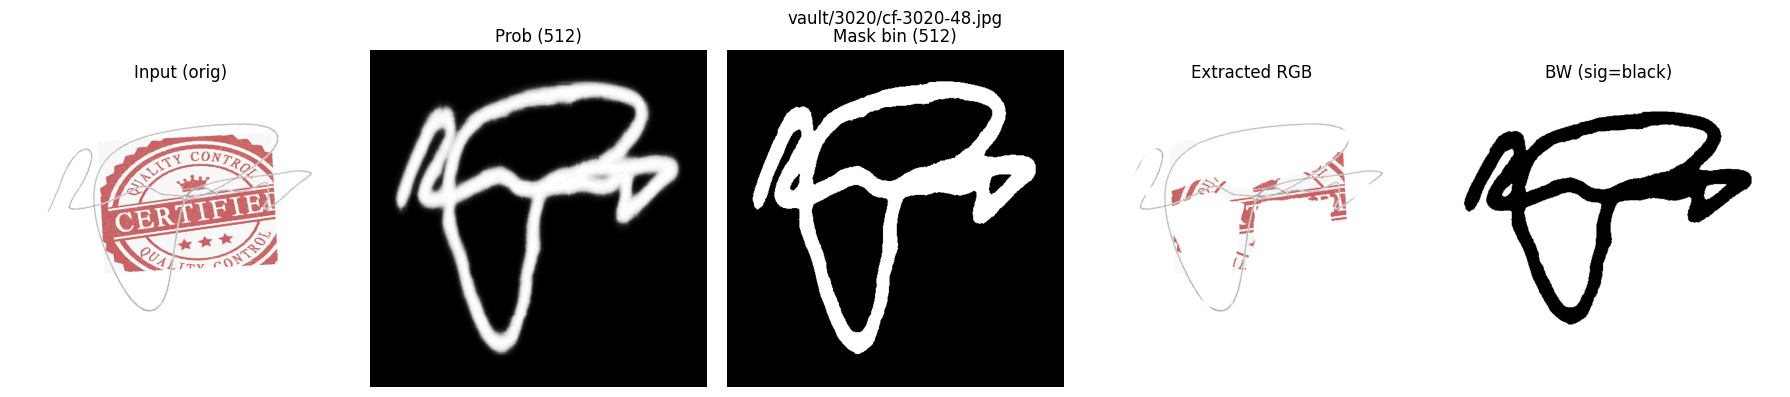

Saved: unet_extracted_rgb.png, unet_signature_bw.png


In [34]:
MY_IMG = "vault/3020/cf-3020-48.jpg"   # <-- put your image path here

orig, prob512, bin512, bin_orig, extracted_rgb, out_bw = run_unet_on_image(
    model, MY_IMG, thr=0.35, do_close=True
)

show_unet_result(orig, prob512, bin512, extracted_rgb, out_bw, title=MY_IMG)

# optional: save outputs
Image.fromarray(extracted_rgb).save("unet_extracted_rgb.png")
Image.fromarray(out_bw).save("unet_signature_bw.png")
print("Saved: unet_extracted_rgb.png, unet_signature_bw.png")

# Duplicate Single Image Test Cell: Same inference block repeated (safe to remove later)

In [ ]:
MY_IMG = "vault/3020/cf-3020-48.jpg"   # <-- put your image path here

orig, prob512, bin512, bin_orig, extracted_rgb, out_bw = run_unet_on_image(
    model, MY_IMG, thr=0.35, do_close=True
)

show_unet_result(orig, prob512, bin512, extracted_rgb, out_bw, title=MY_IMG)

# optional: save outputs
Image.fromarray(extracted_rgb).save("unet_extracted_rgb.png")
Image.fromarray(out_bw).save("unet_signature_bw.png")
print("Saved: unet_extracted_rgb.png, unet_signature_bw.png")